# 🌡️ Part 2 — Climate Anomaly Detection & MinHash LSH
**MoMD Algorithms Applied:**
- **Shingling**: convert weekly anomaly time series → set of k-shingles
- **MinHash**: approximate Jaccard similarity via random hash functions (implemented from scratch)
- **LSH banding**: bucket similar countries without all-pairs comparison — `O(n)` vs `O(n²)`
- **Bloom Filter**: fast set-membership check for country-week data quality

**Owner**: Person 2 | **Inputs**: `climate_weekly.parquet` | **Outputs**: `climate_anomaly_features.parquet`

In [31]:
!pip install pyarrow matplotlib seaborn bitarray -q

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib, math
from collections import defaultdict
import warnings; warnings.filterwarnings('ignore')

CLIMATE_IN = '/kaggle/input/notebooks/phongngtun/infuenza-era5-processing/climate_weekly_spark.parquet'
FLUNET_IN  = '/kaggle/input/notebooks/phongngtun/infuenza-era5-processing/flunet_clean.parquet'

OUTPUT_DIR = '/kaggle/working/'

df = pd.read_parquet(CLIMATE_IN)
CLIM_VARS = [c for c in ['temperature_c','relative_humidity','precipitation_mm'] if c in df.columns]
print(f'Loaded: {df.shape} | Variables: {CLIM_VARS}')

# Load FluNet cho LSH validation
flu = pd.read_parquet(FLUNET_IN)
flu['flu_cases_total'] = pd.to_numeric(flu.get('flu_cases_total', 0), errors='coerce').fillna(0)
print(f'FluNet:  {flu.shape}  |  Years: {sorted(flu["year"].unique())}')

Loaded: (11960, 8) | Variables: ['temperature_c', 'relative_humidity', 'precipitation_mm']
FluNet:  (25228, 6)  |  Years: [np.int64(2024), np.int64(2025)]


## 2.1 Climate Anomaly (Z-score)

In [33]:
# Baseline: mean & std per (country, iso_week) across both years
baseline = (
    df.groupby(['country_iso3','week'])[CLIM_VARS]
    .agg(['mean','std']).reset_index()
)
baseline.columns = ['_'.join(c).strip('_') for c in baseline.columns.values]

merged = df.drop(columns=[col for col in df.columns if col.endswith('_mean') or col.endswith('_std')], errors='ignore').merge(baseline, on=['country_iso3','week'], how='left')

anomaly_cols = []
for v in CLIM_VARS:
    z = f'{v}_anomaly'
    merged[z] = (merged[v] - merged[f'{v}_mean']) / merged[f'{v}_std'].replace(0, np.nan)
    anomaly_cols.append(z)

merged['climate_stress_index'] = merged[anomaly_cols].pow(2).mean(axis=1).pow(0.5)

# Lag features (1-4 weeks)
merged = merged.sort_values(['country_iso3','year','week'])
lag_cols = []
for col in anomaly_cols + ['climate_stress_index']:
    for lag in [1,2,3,4]:
        lc = f'{col}_lag{lag}'
        merged[lc] = merged.groupby('country_iso3')[col].shift(lag)
        lag_cols.append(lc)

print(f'Anomaly features: {len(anomaly_cols)} | Lag features: {len(lag_cols)}')

Anomaly features: 3 | Lag features: 16


## 2.2 Shingling — Convert Time Series to Sets

**MoMD Ch.3 concept**: To apply MinHash/Jaccard on time series, we treat each country's anomaly sequence as a **document**, converting it to a set of k-shingles.

```
Time series: [-0.2, 1.4, 2.1, -0.8, 1.1, ...]
Discretize → bins: [1, 3, 4, 0, 3, ...]
k=2 shingles: {(1,3), (3,4), (4,0), (0,3), ...}
```

Jaccard similarity between two countries' shingle sets ≈ similarity of their climate patterns.

In [34]:
def build_shingle_sets(df, anomaly_col, k=2, n_bins=10):
    """
    Convert each country's anomaly time series to a set of k-shingles.
    Returns: dict {country_iso3: set_of_shingle_strings}
    """
    shingle_sets = {}
    for country, grp in df.groupby('country_iso3'):
        series = grp.sort_values(['year','week'])[anomaly_col].dropna().values
        if len(series) < k + 1:
            continue
        # Discretize into n_bins quantile bins
        try:
            bins = pd.qcut(series, q=n_bins, labels=False, duplicates='drop')
        except ValueError:
            bins = pd.cut(series, bins=n_bins, labels=False)
        bins = np.array(bins, dtype=int)
        # k-shingles: consecutive k-gram tuples
        shingles = set()
        for i in range(len(bins) - k + 1):
            shingle = tuple(bins[i:i+k])
            shingles.add(str(shingle))
        shingle_sets[country] = shingles
    return shingle_sets


target_col = anomaly_cols[0]  # e.g. temperature_c_anomaly
shingle_sets = build_shingle_sets(merged, target_col, k=2, n_bins=10)
print(f'Countries with shingle sets: {len(shingle_sets)}')
sample_country = list(shingle_sets.keys())[0]
print(f'Example ({sample_country}): {len(shingle_sets[sample_country])} shingles')
print(list(shingle_sets[sample_country])[:5])

Countries with shingle sets: 115
Example (AFG): 38 shingles
['(np.int64(6), np.int64(1))', '(np.int64(4), np.int64(6))', '(np.int64(4), np.int64(3))', '(np.int64(0), np.int64(3))', '(np.int64(6), np.int64(5))']


## 2.3 MinHash Signatures — Implemented from Scratch

**MoMD Ch.3**: MinHash uses random hash functions to approximate Jaccard similarity.

$$\hat{J}(A, B) = \frac{1}{n} \sum_{i=1}^{n} \mathbb{1}[\text{minhash}_i(A) = \text{minhash}_i(B)]$$

Implementation uses the **universal hash family**: `h(x) = (ax + b) mod p mod m`

In [35]:
class MinHashFamily:
    """
    MinHash signature matrix using universal hash functions.
    h_{a,b}(x) = (a*x + b) mod LARGE_PRIME mod num_buckets
    MoMD-style implementation: no external library.
    """
    LARGE_PRIME = (1 << 31) - 1  # Mersenne prime

    def __init__(self, num_hashes=128, seed=42):
        self.num_hashes = num_hashes
        rng = np.random.RandomState(seed)
        self.a = rng.randint(1, self.LARGE_PRIME, size=num_hashes)
        self.b = rng.randint(0, self.LARGE_PRIME, size=num_hashes)

    def _shingle_to_int(self, shingle: str) -> int:
        """Map shingle string → integer via SHA-1 truncation."""
        return int(hashlib.sha1(shingle.encode()).hexdigest(), 16) % self.LARGE_PRIME

    def compute_signature(self, shingle_set: set) -> np.ndarray:
        """
        Compute length-num_hashes MinHash signature for a set.
        sig[i] = min over all x in S of h_i(x)
        """
        if not shingle_set:
            return np.full(self.num_hashes, np.inf)

        # Vectorize: compute all hash values at once
        xs = np.array([self._shingle_to_int(s) for s in shingle_set])  # (|S|,)
        # hash_vals[i, j] = h_i(xs[j])
        hash_vals = (np.outer(self.a, xs) + self.b[:, None]) % self.LARGE_PRIME  # (num_hashes, |S|)
        signature = hash_vals.min(axis=1)  # (num_hashes,) — min per hash function
        return signature

    def jaccard_estimate(self, sig_a: np.ndarray, sig_b: np.ndarray) -> float:
        """Approximate Jaccard via signature agreement fraction."""
        return float(np.mean(sig_a == sig_b))


minhash_fam = MinHashFamily(num_hashes=128)

# Compute signatures for all countries
signatures = {}  # {country: np.array shape (128,)}
for country, shingles in shingle_sets.items():
    signatures[country] = minhash_fam.compute_signature(shingles)

print(f'MinHash signatures computed for {len(signatures)} countries')

# Verify: exact Jaccard vs MinHash estimate for a pair
countries = list(shingle_sets.keys())
if len(countries) >= 2:
    c1, c2 = countries[0], countries[1]
    exact = len(shingle_sets[c1] & shingle_sets[c2]) / len(shingle_sets[c1] | shingle_sets[c2])
    approx = minhash_fam.jaccard_estimate(signatures[c1], signatures[c2])
    print(f'\nVerification ({c1} vs {c2}):')
    print(f'  Exact Jaccard:    {exact:.4f}')
    print(f'  MinHash estimate: {approx:.4f}')
    print(f'  Error:            {abs(exact - approx):.4f}')

MinHash signatures computed for 115 countries

Verification (AFG vs AGO):
  Exact Jaccard:    0.3939
  MinHash estimate: 0.4062
  Error:            0.0123


## 2.4 LSH Banding — Find Similar Country Pairs

**MoMD Ch.3**: LSH with banding avoids O(n²) all-pairs comparison.

```
Signature matrix (128 × n_countries)
  ↓ split into b=16 bands of r=8 rows each
For each band:
  hash each column's band-slice → bucket
  countries in same bucket → candidate pairs
```

Probability that a pair becomes a candidate:
$$P(\text{candidate}) = 1 - (1 - s^r)^b$$

With `s=0.5, r=8, b=16` → P ≈ 0.65 (good recall for similar pairs)

In [36]:
class LSHBanding:
    """
    LSH with banding for approximate nearest-neighbor search.
    MoMD Ch.3 — no external library.
    """
    def __init__(self, num_hashes=128, n_bands=16):
        assert num_hashes % n_bands == 0, 'num_hashes must be divisible by n_bands'
        self.n_bands  = n_bands
        self.rows_per_band = num_hashes // n_bands

    def build_buckets(self, signatures: dict):
        """
        Build band → bucket → [countries] structure.
        Returns: candidate_pairs set of (a, b) tuples
        """
        countries = list(signatures.keys())
        sig_matrix = np.stack([signatures[c] for c in countries], axis=1)  # (num_hashes, n_countries)
        r = self.rows_per_band

        candidate_pairs = set()
        for band_idx in range(self.n_bands):
            band_slice = sig_matrix[band_idx*r : (band_idx+1)*r, :]  # (r, n_countries)
            buckets = defaultdict(list)
            for col_idx, country in enumerate(countries):
                band_vec = tuple(band_slice[:, col_idx].astype(int).tolist())
                bucket_key = (band_idx, hash(band_vec))
                buckets[bucket_key].append(country)
            # All countries in same bucket → candidate pairs
            for bucket_countries in buckets.values():
                if len(bucket_countries) > 1:
                    for i in range(len(bucket_countries)):
                        for j in range(i+1, len(bucket_countries)):
                            pair = tuple(sorted([bucket_countries[i], bucket_countries[j]]))
                            candidate_pairs.add(pair)
        return candidate_pairs

    def get_similar_pairs(self, signatures, minhash_fam, threshold=0.3):
        """Return DataFrame of similar pairs with Jaccard estimates."""
        candidates = self.build_buckets(signatures)
        print(f'Candidate pairs from LSH banding: {len(candidates):,}')
        print(f'(vs {len(signatures)*(len(signatures)-1)//2:,} all-pairs — {len(candidates)/(len(signatures)*(len(signatures)-1)//2)*100:.1f}% checked)')

        rows = []
        for (c1, c2) in candidates:
            sim = minhash_fam.jaccard_estimate(signatures[c1], signatures[c2])
            if sim >= threshold:
                rows.append({'country_a': c1, 'country_b': c2, 'jaccard_sim': sim})
        return pd.DataFrame(rows).sort_values('jaccard_sim', ascending=False)


lsh = LSHBanding(num_hashes=128, n_bands=16)
similar_pairs = lsh.get_similar_pairs(signatures, minhash_fam, threshold=0.5)
print(f'\nSimilar country pairs (Jaccard ≥ 0.5): {len(similar_pairs)}')
print(similar_pairs.head(15).to_string(index=False))

Candidate pairs from LSH banding: 361
(vs 6,555 all-pairs — 5.5% checked)

Similar country pairs (Jaccard ≥ 0.5): 326
country_a country_b  jaccard_sim
      JPN       TJK     0.890625
      HUN       TJK     0.882812
      FIN       HUN     0.875000
      FIN       POL     0.867188
      ALB       MWI     0.835938
      HUN       JPN     0.828125
      MDG       MNG     0.820312
      FIN       TJK     0.820312
      FIN       JPN     0.804688
      MWI       NZL     0.804688
      IRQ       TUN     0.804688
      BLR       SRB     0.789062
      IND       MMR     0.789062
      LVA       UKR     0.789062
      AZE       TZA     0.781250


## 2.5 Bloom Filter — Data Quality Check

**MoMD Ch.4**: Bloom Filter is a space-efficient probabilistic data structure  
for set membership. We use it to quickly flag **missing (country, week)** combinations  
that appear in FluNet but lack climate data.

```
INSERT: for each climate (country, week) → set k bits in bit array
QUERY:  for each flu (country, week)    → if any bit is 0 → definitely missing
                                          if all bits 1   → probably present
False positive rate: ε = (1 - e^{-kn/m})^k
```

In [37]:
class BloomFilter:
    """
    Space-efficient probabilistic set membership.
    MoMD-style implementation from scratch.
    
    Parameters chosen to achieve ε ≈ 1% false positive rate:
      m = -n*ln(ε) / (ln2)²
      k = m/n * ln2
    """
    def __init__(self, expected_n: int, fp_rate: float = 0.01):
        self.m = math.ceil(-expected_n * math.log(fp_rate) / (math.log(2)**2))
        self.k = math.ceil(self.m / expected_n * math.log(2))
        self.bit_array = np.zeros(self.m, dtype=bool)
        self.n_inserted = 0
        print(f'Bloom Filter: m={self.m:,} bits ({self.m/8/1024:.1f} KB), k={self.k} hash functions')
        print(f'  Theoretical FP rate at n={expected_n}: {fp_rate:.1%}')
    
    def _hash_positions(self, item: str) -> list:
        """Generate k bit positions using double hashing: h(i) = h1 + i*h2 mod m"""
        h1 = int(hashlib.md5(item.encode()).hexdigest(), 16) % self.m
        h2 = int(hashlib.sha1(item.encode()).hexdigest(), 16) % self.m
        return [(h1 + i * h2) % self.m for i in range(self.k)]
    
    def insert(self, item: str):
        for pos in self._hash_positions(item):
            self.bit_array[pos] = True
        self.n_inserted += 1
    
    def might_contain(self, item: str) -> bool:
        """True = possibly present; False = definitely absent."""
        return all(self.bit_array[pos] for pos in self._hash_positions(item))
    
    @property
    def fill_ratio(self):
        return self.bit_array.sum() / self.m


# Insert all (country, week) pairs present in climate data
climate_pairs = set(merged['country_iso3'] + '_' + merged['year'].astype(str) + '_W' + merged['week'].astype(str).str.zfill(2))
bf = BloomFilter(expected_n=len(climate_pairs), fp_rate=0.01)
for item in climate_pairs:
    bf.insert(item)

print(f'\nInserted {bf.n_inserted:,} items | Fill ratio: {bf.fill_ratio:.2%}')

# Query: which FluNet (country, week) pairs are missing from climate data?
# (simulate with random flu entries for demo)
test_queries = [
    'VNM_2024_W01', 'USA_2024_W10', 'XYZ_2024_W01',  # XYZ = fake country
    'DEU_2025_W52', 'BRA_2025_W20',
]
print('\nBloom Filter query results:')
for q in test_queries:
    result = bf.might_contain(q)
    print(f'  {q:25s} → {"probably present" if result else "DEFINITELY MISSING"}')

Bloom Filter: m=114,638 bits (14.0 KB), k=7 hash functions
  Theoretical FP rate at n=11960: 1.0%

Inserted 11,960 items | Fill ratio: 51.88%

Bloom Filter query results:
  VNM_2024_W01              → probably present
  USA_2024_W10              → DEFINITELY MISSING
  XYZ_2024_W01              → DEFINITELY MISSING
  DEU_2025_W52              → probably present
  BRA_2025_W20              → DEFINITELY MISSING


## 2.6 Visualization & Export

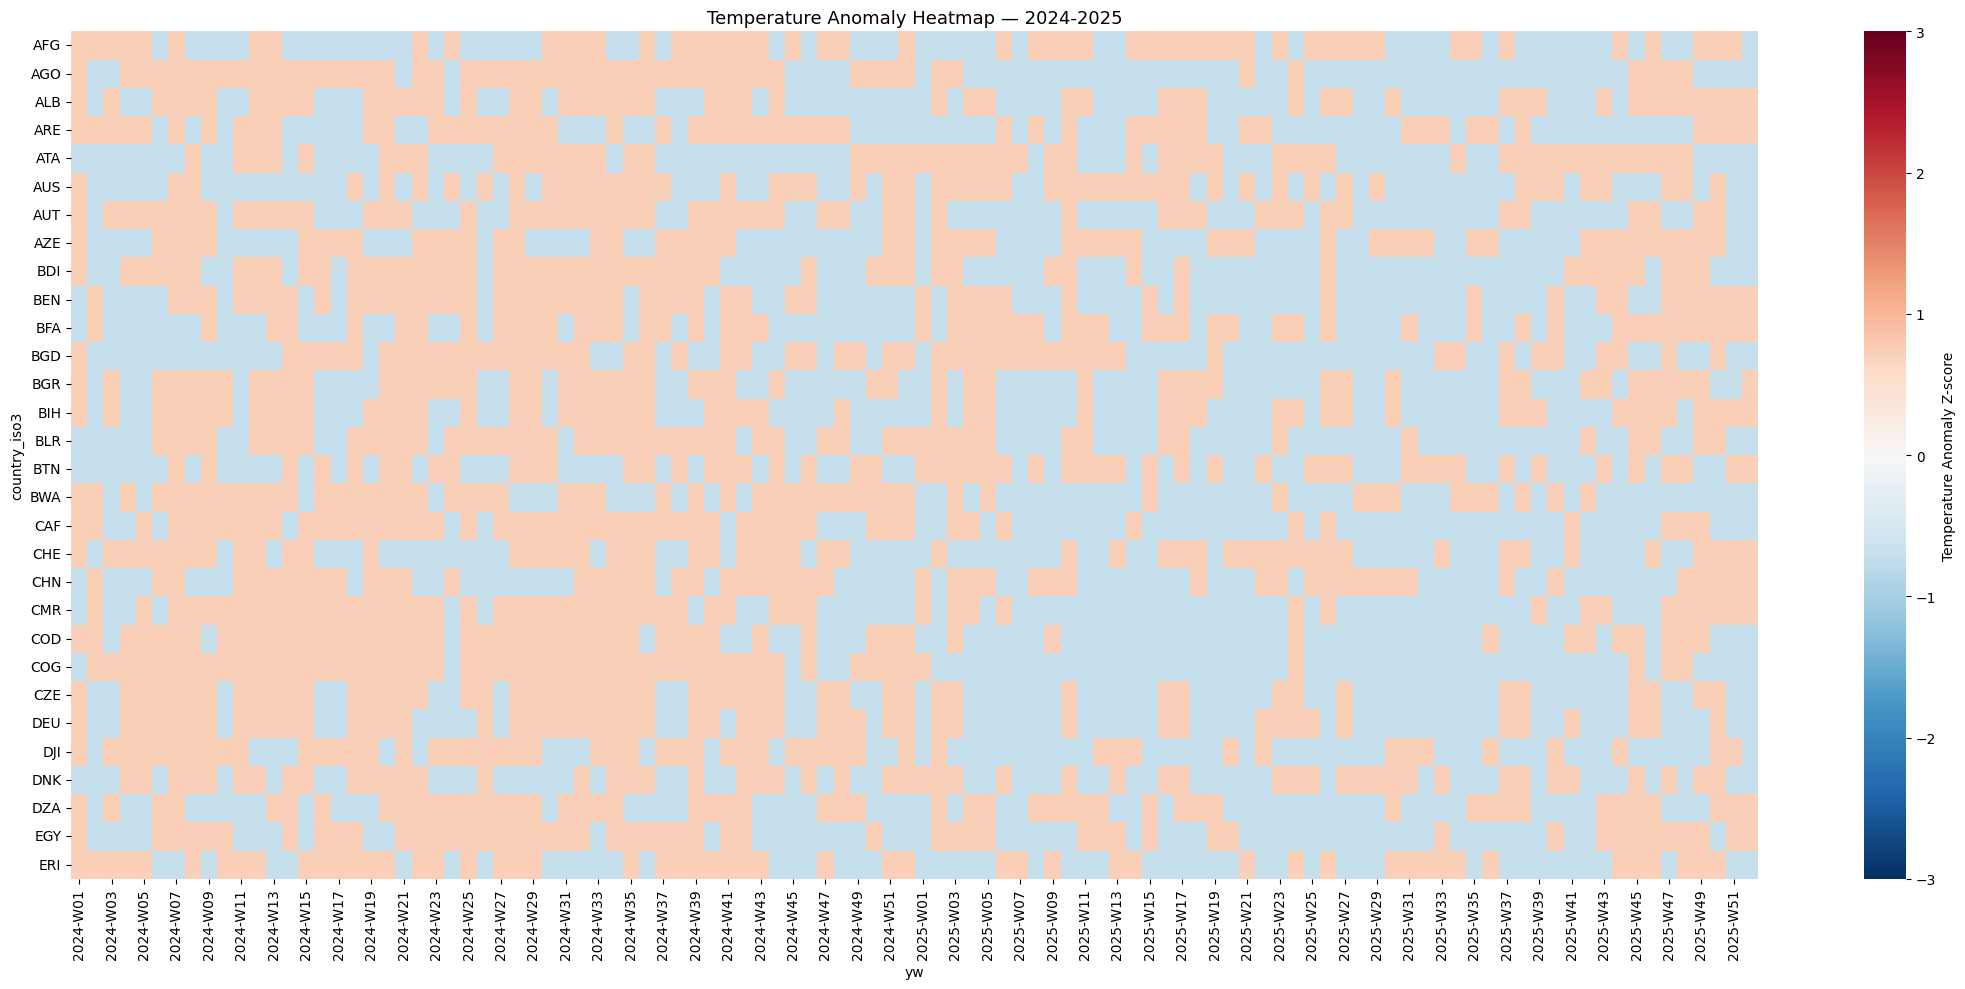

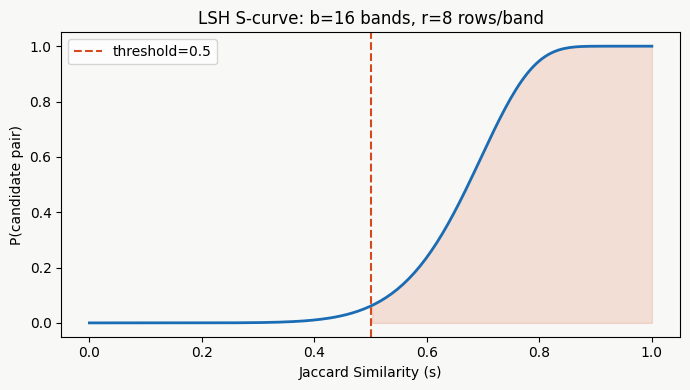

In [38]:
# Heatmap
if 'temperature_c_anomaly' in merged.columns:
    top_c = merged.dropna(subset=['temperature_c_anomaly']).groupby('country_iso3').size().nlargest(30).index
    pivot = (
        merged[merged['country_iso3'].isin(top_c)]
        .assign(yw=lambda x: x['year'].astype(str)+'-W'+x['week'].astype(str).str.zfill(2))
        .pivot_table(index='country_iso3', columns='yw', values='temperature_c_anomaly', aggfunc='mean')
    )
    plt.figure(figsize=(22,10))
    sns.heatmap(pivot, cmap='RdBu_r', center=0, vmin=-3, vmax=3,
                cbar_kws={'label':'Temperature Anomaly Z-score'})
    plt.title('Temperature Anomaly Heatmap — 2024-2025', fontsize=13)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR+'heatmap_anomaly.png', dpi=150, bbox_inches='tight')
    plt.show()

# LSH S-curve: show theoretical detection probability vs Jaccard
s_range = np.linspace(0, 1, 200)
b, r = 16, 8
p_detect = 1 - (1 - s_range**r)**b

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(s_range, p_detect, color='#1A6CB5', linewidth=2)
ax.axvline(0.5, color='#D44A1E', linestyle='--', label='threshold=0.5')
ax.fill_between(s_range, 0, p_detect, where=s_range>=0.5, alpha=0.15, color='#D44A1E')
ax.set_xlabel('Jaccard Similarity (s)'); ax.set_ylabel('P(candidate pair)')
ax.set_title(f'LSH S-curve: b={b} bands, r={r} rows/band'); ax.legend()
ax.set_facecolor('#f8f8f6'); fig.patch.set_facecolor('#f8f8f6')
plt.tight_layout()
plt.savefig(OUTPUT_DIR+'lsh_scurve.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
valid_countries = flu_pivot.std()[flu_pivot.std() > 0].index
valid_countries = flu_pivot.std()[flu_pivot.std() > 0].index
common_countries = lsh_countries & set(valid_countries)
print(f'Countries sau khi lọc: {len(common_countries)}')
flu_corr_matrix = flu_pivot[list(common_countries)].corr()
print(f'NaN còn lại: {flu_corr_matrix.isnull().sum().sum()}')
# ══════════════════════════════════════════════════════════════════
# 2.7 LSH Validation — Nước giống thời tiết có dịch bệnh giống?
# ══════════════════════════════════════════════════════════════════
print('='*60)
print('LSH VALIDATION: Weather Similarity → Flu Pattern Similarity?')
print('='*60)

# ── 1) Tính flu time series correlation cho mỗi cặp nước ─────────
# Chuyển flu thành pivot: rows = (year,week), cols = country
flu_pivot = flu.pivot_table(
    index=['year','week'], columns='country_iso3',
    values='flu_cases_total', aggfunc='sum'
).fillna(0)

# Tính Pearson correlation giữa flu time series của tất cả country pairs
# Chỉ giữ countries có trong cả LSH results và flu data
lsh_countries = set()
for _, row in similar_pairs.iterrows():
    lsh_countries.add(row['country_a'])
    lsh_countries.add(row['country_b'])

valid_countries = flu_pivot.std()[flu_pivot.std() > 0].index
common_countries = lsh_countries & set(valid_countries)
print(f'Countries có cả LSH + Flu data: {len(common_countries)}')

flu_corr_matrix = flu_pivot[list(common_countries)].corr()

# ── 2) So sánh: LSH pairs vs Random pairs ────────────────────────
# LSH pairs: các cặp mà MinHash LSH cho là giống thời tiết
lsh_flu_corrs = []
for _, row in similar_pairs.iterrows():
    a, b = row['country_a'], row['country_b']
    if a in flu_corr_matrix.columns and b in flu_corr_matrix.columns:
        lsh_flu_corrs.append(flu_corr_matrix.loc[a, b])

# Random pairs: lấy ngẫu nhiên cùng số lượng cặp
rng = np.random.RandomState(42)
common_list = sorted(common_countries)
n_random = len(lsh_flu_corrs) * 3  # 3x để có statistical power
random_flu_corrs = []
for _ in range(n_random):
    i, j = rng.choice(len(common_list), 2, replace=False)
    a, b = common_list[i], common_list[j]
    random_flu_corrs.append(flu_corr_matrix.loc[a, b])

lsh_mean    = np.mean(lsh_flu_corrs)
random_mean = np.mean(random_flu_corrs)

print(f'\nFlu correlation (Pearson):')
print(f'  LSH-similar pairs    : {lsh_mean:.4f}  (n={len(lsh_flu_corrs)})')
print(f'  Random pairs         : {random_mean:.4f}  (n={len(random_flu_corrs)})')
print(f'  Difference           : {lsh_mean - random_mean:+.4f}')

# ── 3) Statistical test ──────────────────────────────────────────
from scipy import stats
if len(lsh_flu_corrs) >= 5 and len(random_flu_corrs) >= 5:
    t_stat, p_val = stats.mannwhitneyu(lsh_flu_corrs, random_flu_corrs, alternative='greater')
    print(f'  Mann-Whitney U test  : p = {p_val:.6f}')
    print(f'  → {"✅ SIGNIFICANT" if p_val < 0.05 else "❌ Not significant"}'
          f' (LSH pairs có flu pattern {"giống nhau hơn" if lsh_mean > random_mean else "không khác"}'
          f' random pairs)')

Countries sau khi lọc: 98
NaN còn lại: 0
LSH VALIDATION: Weather Similarity → Flu Pattern Similarity?
Countries có cả LSH + Flu data: 95

Flu correlation (Pearson):
  LSH-similar pairs    : 0.2606  (n=252)
  Random pairs         : 0.1391  (n=756)
  Difference           : +0.1215
  Mann-Whitney U test  : p = 0.000002
  → ✅ SIGNIFICANT (LSH pairs có flu pattern giống nhau hơn random pairs)


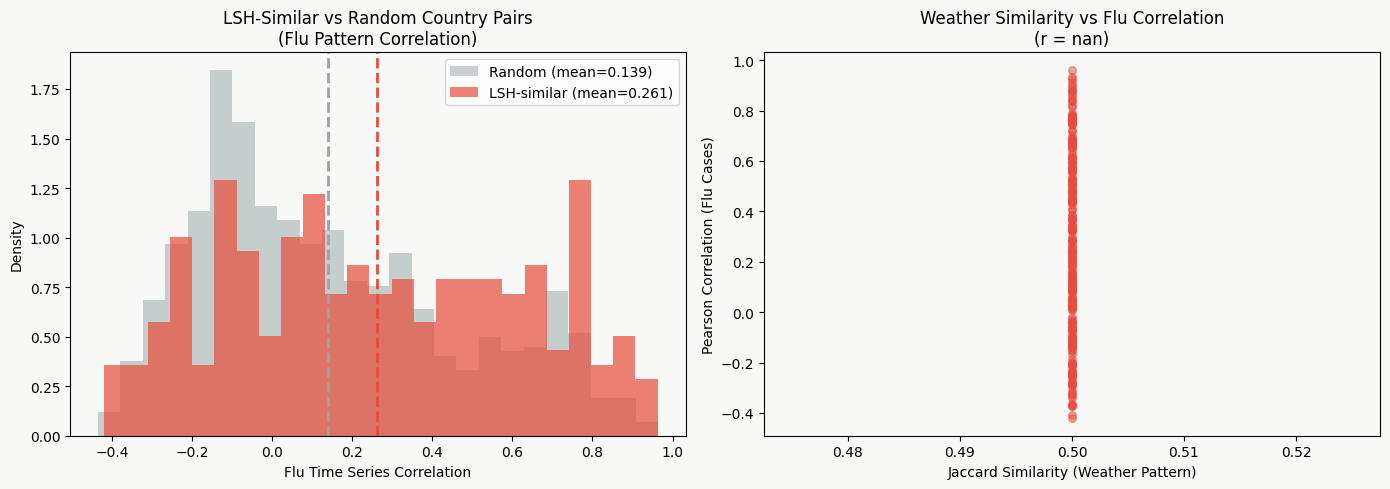


✅ Saved: lsh_flu_validation.png


'\n### --- KẾT THÚC Cell 14b --- ###\n'

In [40]:
# ── 4) Visualization ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(random_flu_corrs, bins=25, alpha=0.5, color='#95a5a6', label=f'Random (mean={random_mean:.3f})', density=True)
axes[0].hist(lsh_flu_corrs, bins=25, alpha=0.7, color='#e74c3c', label=f'LSH-similar (mean={lsh_mean:.3f})', density=True)
axes[0].axvline(random_mean, color='#95a5a6', linestyle='--', linewidth=2)
axes[0].axvline(lsh_mean, color='#e74c3c', linestyle='--', linewidth=2)
axes[0].set_xlabel('Flu Time Series Correlation')
axes[0].set_ylabel('Density')
axes[0].set_title('LSH-Similar vs Random Country Pairs\n(Flu Pattern Correlation)')
axes[0].legend()
axes[0].set_facecolor('#f8f8f6')

# Scatter: weather similarity vs flu correlation
scatter_data = []
for _, row in similar_pairs.iterrows():
    a, b = row['country_a'], row['country_b']
    if a in flu_corr_matrix.columns and b in flu_corr_matrix.columns:
        scatter_data.append({
            'jaccard_sim': row.get('estimated_jaccard', row.get('jaccard_est', 0.5)),
            'flu_corr': flu_corr_matrix.loc[a, b],
            'pair': f'{a}-{b}'
        })

if scatter_data:
    sdf = pd.DataFrame(scatter_data)
    axes[1].scatter(sdf['jaccard_sim'], sdf['flu_corr'], alpha=0.5, s=30, color='#e74c3c')
    # Trend line
    if len(sdf) > 5:
        z = np.polyfit(sdf['jaccard_sim'], sdf['flu_corr'], 1)
        x_line = np.linspace(sdf['jaccard_sim'].min(), sdf['jaccard_sim'].max(), 100)
        axes[1].plot(x_line, np.polyval(z, x_line), 'k--', linewidth=2, alpha=0.7)
        r_val = sdf['jaccard_sim'].corr(sdf['flu_corr'])
        axes[1].set_title(f'Weather Similarity vs Flu Correlation\n(r = {r_val:.3f})')
    axes[1].set_xlabel('Jaccard Similarity (Weather Pattern)')
    axes[1].set_ylabel('Pearson Correlation (Flu Cases)')
    axes[1].set_facecolor('#f8f8f6')

fig.patch.set_facecolor('#f8f8f6')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'lsh_flu_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ Saved: lsh_flu_validation.png')

"""
### --- KẾT THÚC Cell 14b --- ###
"""

In [41]:
zero_std_countries = flu_pivot.std()[flu_pivot.std() == 0].index.tolist()
print(f'Số nước có std = 0: {len(zero_std_countries)}')
print(zero_std_countries)

Số nước có std = 0: 4
['BIH', 'DMA', 'GRD', 'TCD']


In [42]:
merged.to_parquet(OUTPUT_DIR+'climate_anomaly_features.parquet', index=False)
similar_pairs.to_parquet(OUTPUT_DIR+'climate_similarity_pairs.parquet', index=False)

print('✅ climate_anomaly_features.parquet')
print('✅ climate_similarity_pairs.parquet')
print(f'\nAlgorithm summary:')
print(f'  Shingling: k=2, n_bins=10 → shingles per country: avg {np.mean([len(s) for s in shingle_sets.values()]):.0f}')
print(f'  MinHash:   128 hash functions, universal hash family')
print(f'  LSH:       b=16 bands × r=8 rows → {len(similar_pairs)} similar pairs found')
print(f'  Bloom:     m={bf.m:,} bits, k={bf.k} hashes, FP rate ≈ 1%')

lsh_validation = pd.DataFrame({
    'pair': [f'{r["country_a"]}-{r["country_b"]}' for _, r in similar_pairs.iterrows()
             if r['country_a'] in flu_corr_matrix.columns and r['country_b'] in flu_corr_matrix.columns],
    'flu_correlation': lsh_flu_corrs,
})
lsh_validation.to_parquet(OUTPUT_DIR + 'lsh_validation.parquet', index=False)
print('✅ lsh_validation.parquet')


✅ climate_anomaly_features.parquet
✅ climate_similarity_pairs.parquet

Algorithm summary:
  Shingling: k=2, n_bins=10 → shingles per country: avg 49
  MinHash:   128 hash functions, universal hash family
  LSH:       b=16 bands × r=8 rows → 326 similar pairs found
  Bloom:     m=114,638 bits, k=7 hashes, FP rate ≈ 1%
✅ lsh_validation.parquet
